## Project: TCS Stock Price Prediction Using Machine Learning

This project aims to predict the daily closing price of TCS (Tata Consultancy Services) stock using historical data from 2004 to 2023. Through exploratory data analysis, feature engineering, and modeling techniques including Linear Regression, XGBoost, and LSTM, we attempt to build accurate and reliable predictive models. The notebook demonstrates the full pipeline from data preprocessing to model evaluation.


In [45]:
!pip install xgboost

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [47]:
df = pd.read_csv('TCS_stock_history.csv')

In [48]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4463 non-null   object 
 1   Open          4463 non-null   float64
 2   High          4463 non-null   float64
 3   Low           4463 non-null   float64
 4   Close         4463 non-null   float64
 5   Volume        4463 non-null   int64  
 6   Dividends     4463 non-null   float64
 7   Stock Splits  4463 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 279.1+ KB


In [50]:
df['Date'] = pd.to_datetime(df['Date'])

In [51]:
df = df.sort_values('Date')

In [52]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [53]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [54]:
print("From", df['Date'].min(), "to", df['Date'].max())

From 2002-08-12 00:00:00 to 2021-09-30 00:00:00


In [55]:
print(df['Stock Splits'].unique())

[0. 2.]


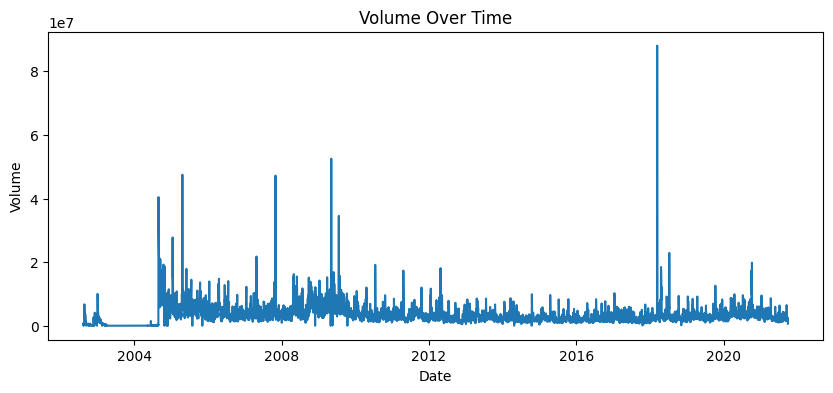

In [56]:
#check outliers in dataset

plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Volume'])
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()


**Exploratory Data Analysis**

**1. Close Price Trend Over Time**

The close price trend of TCS from 2004 to 2023 shows a strong long-term upward trajectory, reflecting the company’s steady growth and market confidence. After a relatively flat phase in the early 2000s, the stock dipped around 2008–2009, consistent with the global financial crisis. From 2010 onwards, TCS experienced accelerated growth, with notable consolidation between 2015 and 2019, followed by a sharp post-pandemic surge starting in 2020, likely driven by digital transformation trends. Despite the overall rise, short-term volatility is visible through periodic pullbacks, suggesting that while the stock is trend-following, fluctuations do occur. This pattern confirms that TCS is well-suited for trend-based modeling approaches, particularly with engineered features like moving averages and time-based lags.

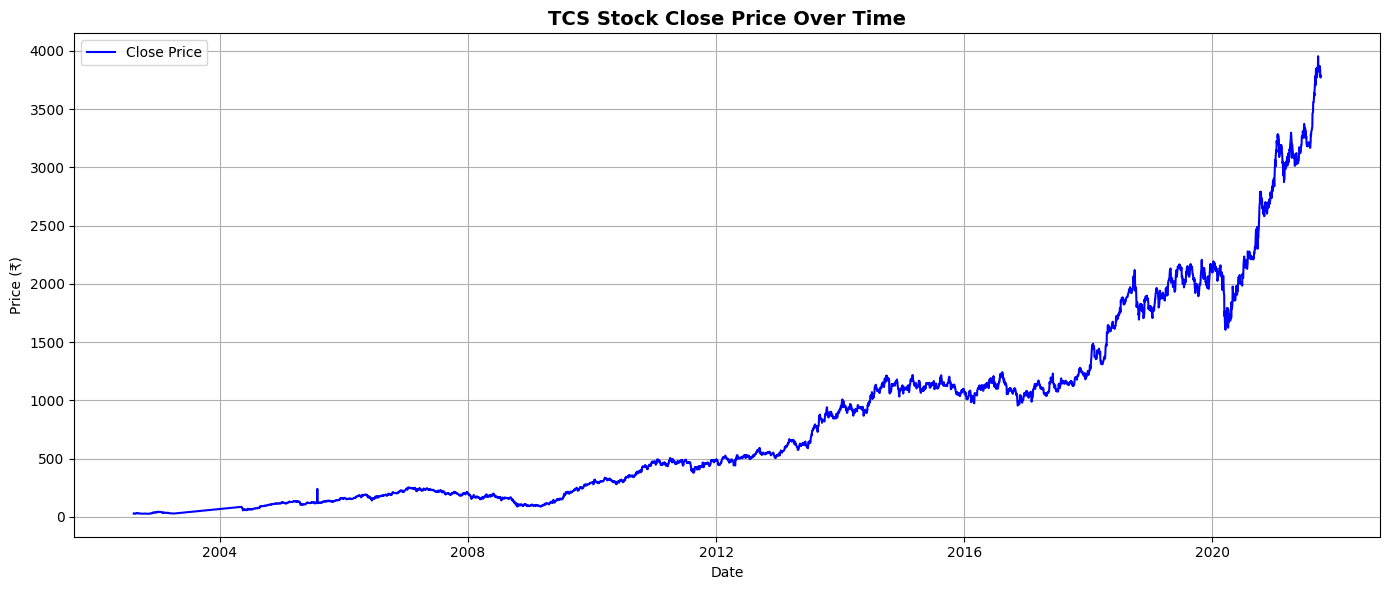

In [57]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.title('TCS Stock Close Price Over Time', fontsize=14, weight='bold')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**2. OHLC (Open, High, Low, Close) comparison.**

**Open Price Over Time**

The open price of TCS has consistently tracked the company’s long-term upward trend, with no major deviations from the close price. This indicates that there are very few gap-ups or gap-downs at the market open, reflecting investor confidence and low overnight news shocks. The growth becomes more pronounced post-2010, especially after 2020, mirroring the close price’s trajectory.

**High Price Over Time**

The daily high prices show minor spikes above the open and close values, suggesting limited intraday surges. These brief spikes are likely linked to earnings reports or market events, particularly during 2007–08 and the post-2020 period. However, the high prices mostly follow the general price trend, indicating that TCS rarely experiences sharp intraday price rallies.

**Low Price Over Time**

The low prices provide a lower bound on daily trading and largely mirror the open and close prices. Occasional dips are visible, especially during periods of market stress (like 2008 and early 2020), but overall, the low prices remain closely packed with other OHLC values, signaling low intraday downside volatility and a generally stable stock.

**Close Price Over Time**

The close price line reinforces TCS’s long-term bullish trend, with clear phases of growth — modest pre-2010, strong from 2010–2015, a pause between 2016–2019, and rapid acceleration after 2020. The close price aligns closely with other OHLC values, confirming that TCS trades within narrow daily ranges and is well-suited for trend-based prediction models.

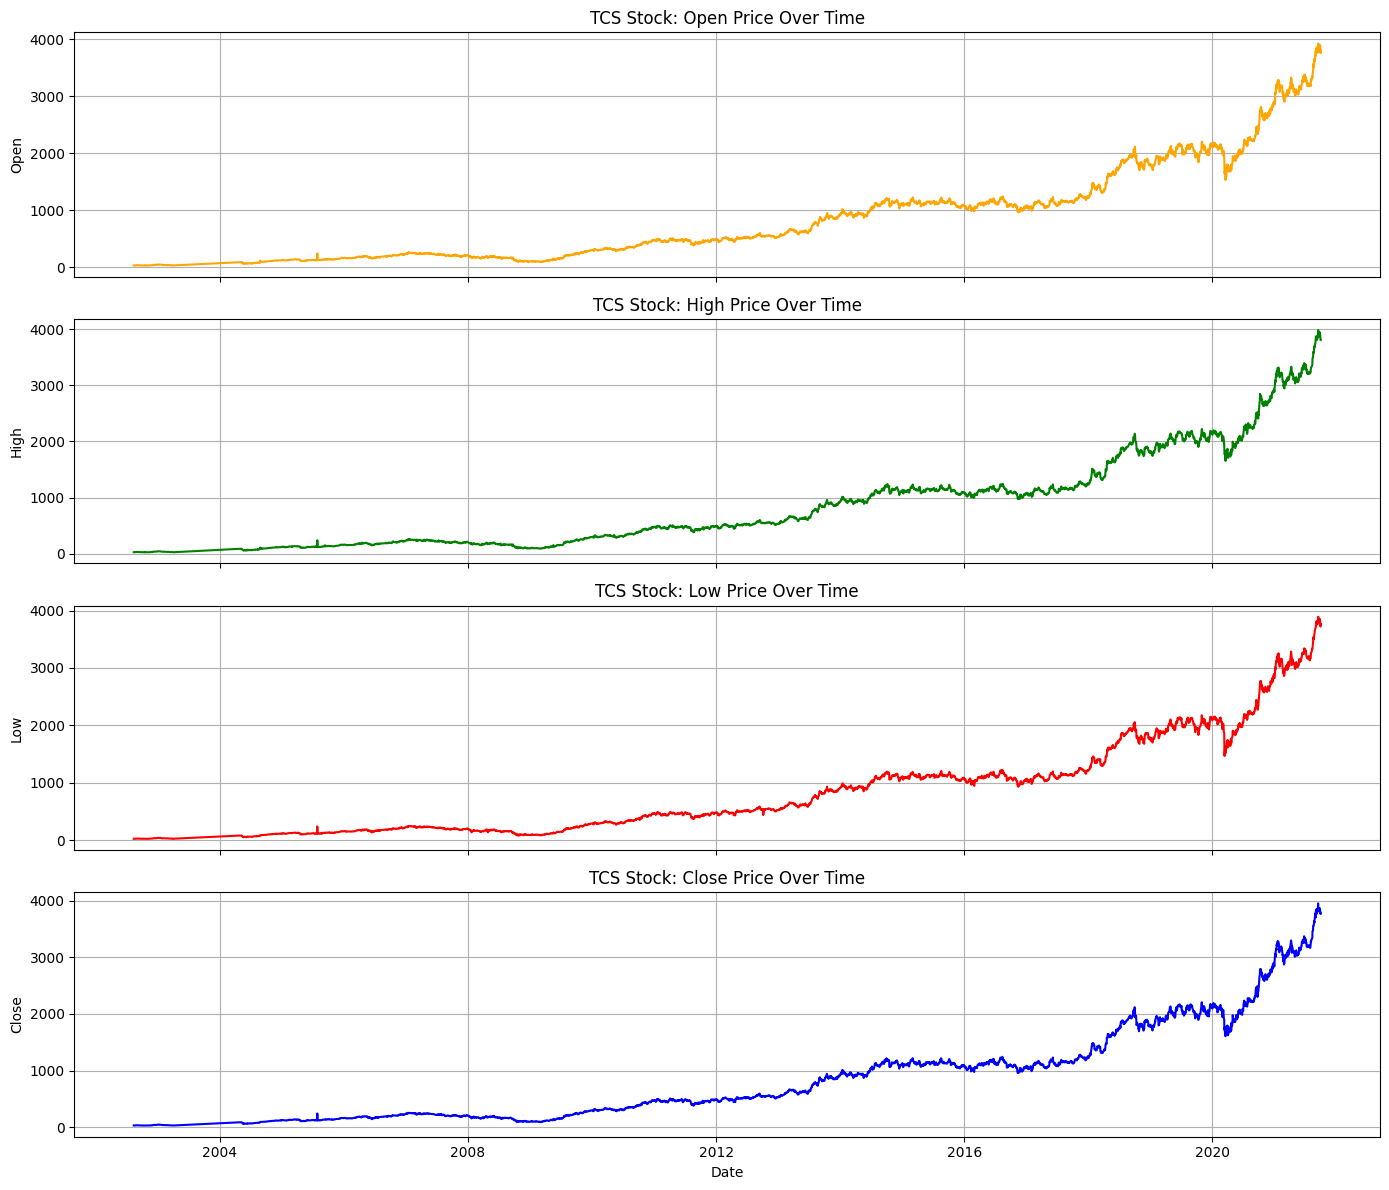

In [58]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df['Date'], df['Open'], color='orange')
axes[0].set_ylabel('Open')
axes[0].set_title('TCS Stock: Open Price Over Time')
axes[0].grid(True)

axes[1].plot(df['Date'], df['High'], color='green')
axes[1].set_ylabel('High')
axes[1].set_title('TCS Stock: High Price Over Time')
axes[1].grid(True)

axes[2].plot(df['Date'], df['Low'], color='red')
axes[2].set_ylabel('Low')
axes[2].set_title('TCS Stock: Low Price Over Time')
axes[2].grid(True)

axes[3].plot(df['Date'], df['Close'], color='blue')
axes[3].set_ylabel('Close')
axes[3].set_title('TCS Stock: Close Price Over Time')
axes[3].set_xlabel('Date')
axes[3].grid(True)

plt.tight_layout()
plt.show()


**3. Volume Over Time**

The trading volume for TCS shows a series of sharp spikes, especially before 2016, with the most prominent surge occurring around 2018, crossing 80 million shares in a single day. These volume spikes likely correspond to corporate actions like stock splits, dividends, or institutional trading activity.

Post-2016, the volume becomes visibly more stable and lower, suggesting a decline in speculative or bulk activity and more consistent institutional participation. This aligns with the stock's maturity in the market. The absence of regular high-volume periods also implies that TCS is not heavily news-driven intraday, and its price movements are more trend-based than volatility-driven.

This stability supports using volume as a supplementary feature, rather than a primary driver in modeling — or transforming it (e.g., using log-volume) if needed.

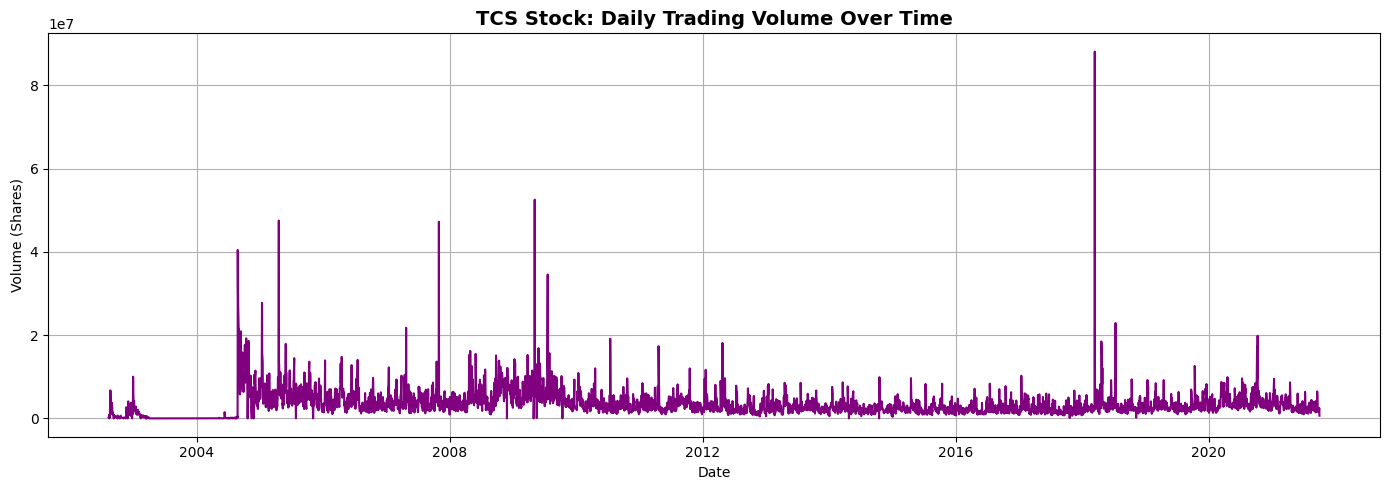

In [59]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Volume'], color='purple')
plt.title('TCS Stock: Daily Trading Volume Over Time', fontsize=14, weight='bold')
plt.xlabel('Date')
plt.ylabel('Volume (Shares)')
plt.grid(True)
plt.tight_layout()
plt.show()

**4. Moving Averages**

**50 Day MA**

The plot clearly shows that both the 50-day (green) and 200-day (red) moving averages have followed a strong upward trajectory since around 2009, confirming TCS’s long-term bullish trend. The close price (black) generally stays above the 200-day MA, which is a classic signal of sustained market strength.

There are a few notable crossover points — particularly in 2008 and again in early 2020 — where the 50-day MA dips below the 200-day MA, signaling temporary bearish phases. These coincide with the global financial crisis and the COVID-19 market dip, respectively. After each crossover, the 50-day MA recovers above the 200-day line, marking a trend reversal back to bullish territory.

Overall, the moving averages reinforce that TCS is momentum-driven and trend-following, making it well-suited for regression-based prediction models. These MAs can also serve as powerful model features to capture trend state.

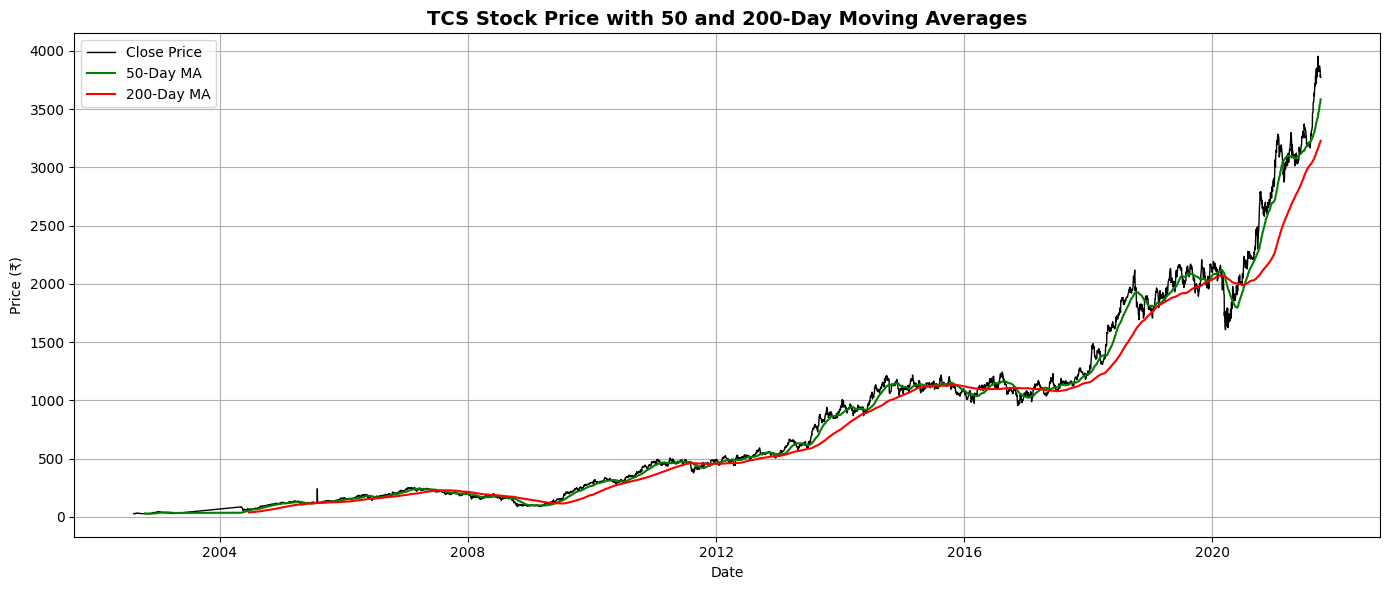

In [60]:
# Calculate moving averages
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1)
# plt.plot(df['Date'], df['MA30'], label='30-Day MA', color='green')
plt.plot(df['Date'], df['MA50'], label='50-Day MA', color='green')
plt.plot(df['Date'], df['MA200'], label='200-Day MA', color='red')

plt.title('TCS Stock Price with 50 and 200-Day Moving Averages', fontsize=14, weight='bold')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**30 Day MA**

The plot shows TCS’s close price with its 30-day (green) and 200-day (red) moving averages. The 30-day MA tracks short-term momentum closely, reacting quickly to price changes, while the 200-day MA reflects the long-term trend. Their consistent upward direction confirms TCS’s overall bullish behavior. Key bearish crossovers appear during 2008 and 2020, signaling short-term corrections, followed by recoveries where the 30-day MA crosses back above the 200-day MA — a classic trend reversal signal. Together, these lines clearly separate short-term fluctuations from long-term market strength.

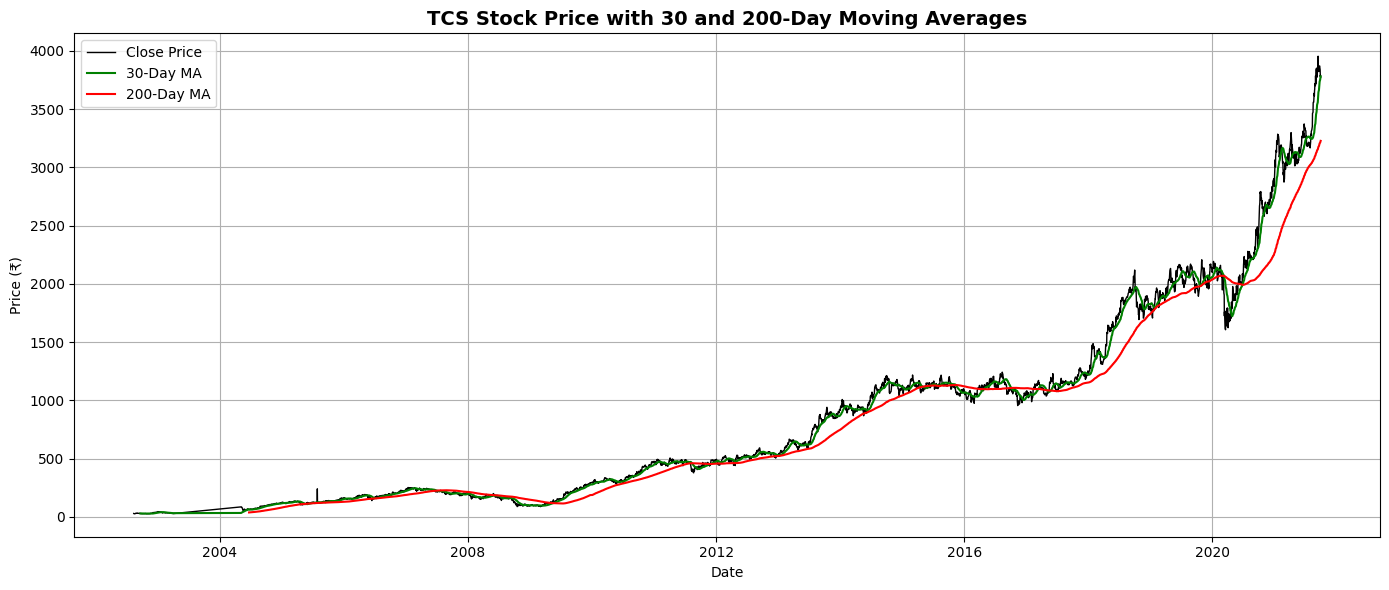

In [61]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1)
plt.plot(df['Date'], df['MA30'], label='30-Day MA', color='green')
# plt.plot(df['Date'], df['MA50'], label='50-Day MA', color='green')
plt.plot(df['Date'], df['MA200'], label='200-Day MA', color='red')

plt.title('TCS Stock Price with 30 and 200-Day Moving Averages', fontsize=14, weight='bold')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**5. Correlation Map**

The heatmap reveals that the Open, High, Low, and Close prices are perfectly correlated (1.00) with each other. This indicates they move in near-perfect unison, which is expected in stock data — these values are all derived from the same trading day and reflect tightly coupled price behavior. Including all of them in a model may lead to redundancy or multicollinearity.

Meanwhile, Volume shows a weak negative correlation (~ -0.15) with the price columns, implying that trading volume tends to slightly drop as prices rise — but the relationship is not strong enough to be predictive on its own.

Dividends and Stock Splits exhibit negligible or no correlation with price or volume, as these are infrequent events and likely don't impact daily price movement in a linear way.

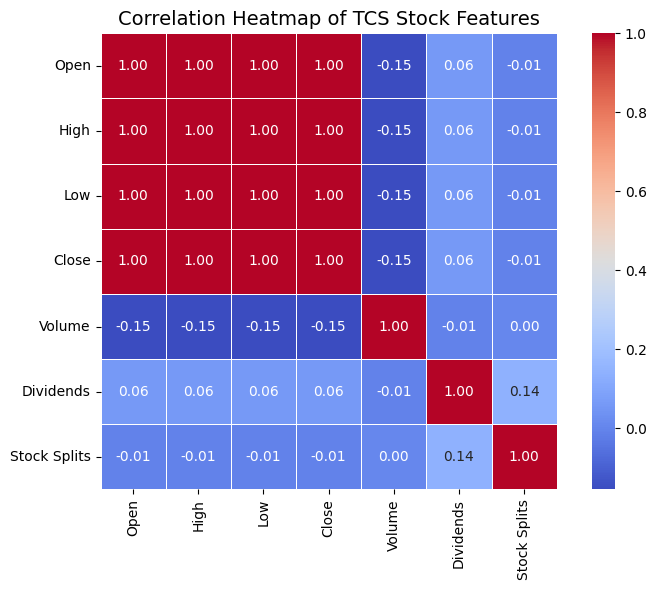

In [62]:
corr_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of TCS Stock Features', fontsize=14)
plt.tight_layout()
plt.show()


**Volume vs Close Price**

The scatter plot of Volume vs Close Price for TCS reveals a dense vertical clustering at low volume levels, indicating that the majority of trading days had relatively low trading volume (generally under ~20 million shares). Within this dense region, Close Prices span a wide range—from very low to nearly ₹4000—showing that price has increased over time even with modest daily volume.

There are a few sparse outliers on the right side with extremely high volume (e.g., above 40–80 million), but these do not consistently correspond to particularly high or low closing prices. This implies that spikes in trading volume may be due to exceptional events (e.g., announcements, stock splits), rather than routine price shifts.

Overall, there’s no strong linear or obvious nonlinear relationship between volume and close price, which aligns with the earlier correlation value near zero (from the heatmap). This suggests that volume alone is not a reliable predictor of daily closing price movement for TCS.

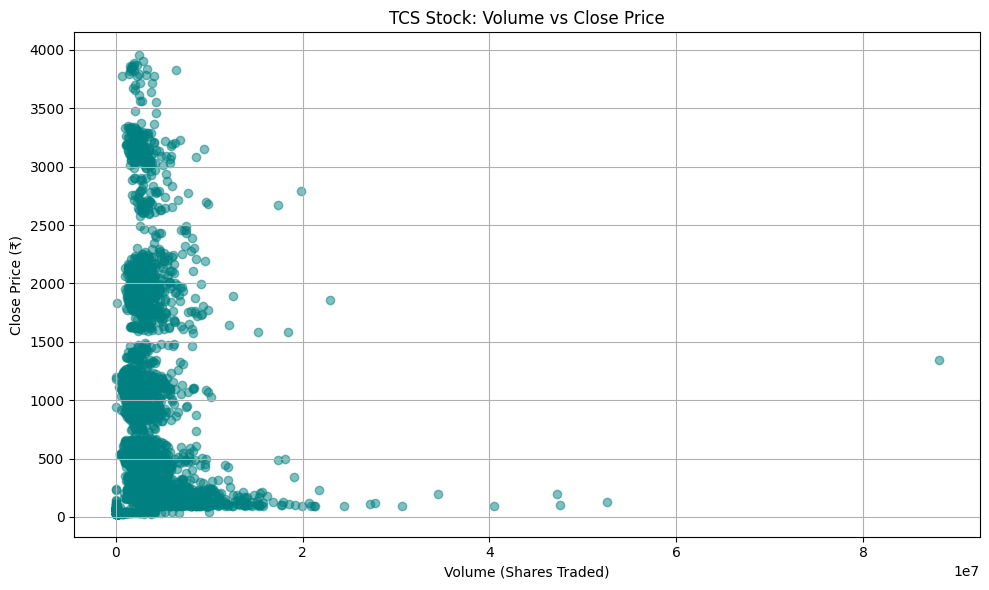

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Volume'], df['Close'], alpha=0.5, color='teal')
plt.title('TCS Stock: Volume vs Close Price')
plt.xlabel('Volume (Shares Traded)')
plt.ylabel('Close Price (₹)')
plt.grid(True)
plt.tight_layout()
plt.show()


**Dividends vs Close Price**

The scatter plot of Dividends vs Close Price for TCS shows that the majority of data points are concentrated at or near zero on the dividend axis, indicating that dividend payouts are infrequent events rather than daily occurrences. Among the non-zero dividend instances, there appears to be a weak positive trend where higher dividends loosely correspond to higher stock prices, but the relationship is not strong or consistent. A few high-dividend outliers (e.g., ₹10, ₹20, ₹40) are associated with a wide range of closing prices, suggesting that dividend announcements may influence stock prices to some extent, but not in a predictable or dominant way. Overall, the plot indicates minimal direct correlation between daily closing prices and dividend payouts.

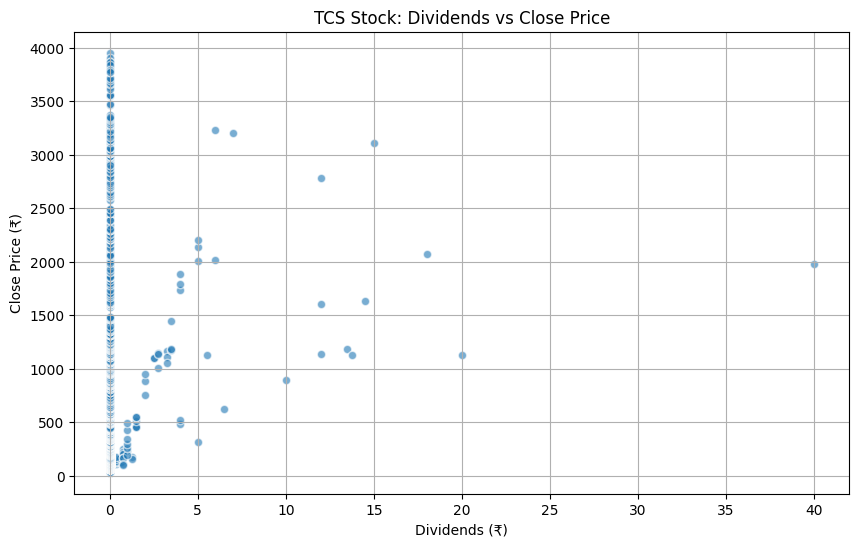

In [64]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Dividends'], df['Close'], alpha=0.6, edgecolors='w')
plt.title('TCS Stock: Dividends vs Close Price')
plt.xlabel('Dividends (₹)')
plt.ylabel('Close Price (₹)')
plt.grid(True)
plt.show()


**Stock Splits vs Close Price**

The plot reveals that stock splits are extremely rare events in the dataset, with only a few instances of a split value of 2.0. The vast majority of trading days have no splits (0.0), forming a dense vertical cluster. The few points corresponding to a split of 2.0 show close prices spread across a range, suggesting that splits occurred at significantly different price levels. However, due to the scarcity of such events, no strong or consistent relationship between stock splits and close prices can be inferred from this data alone. The split effect, while potentially impactful on price, is not frequent enough here to demonstrate a visible trend.

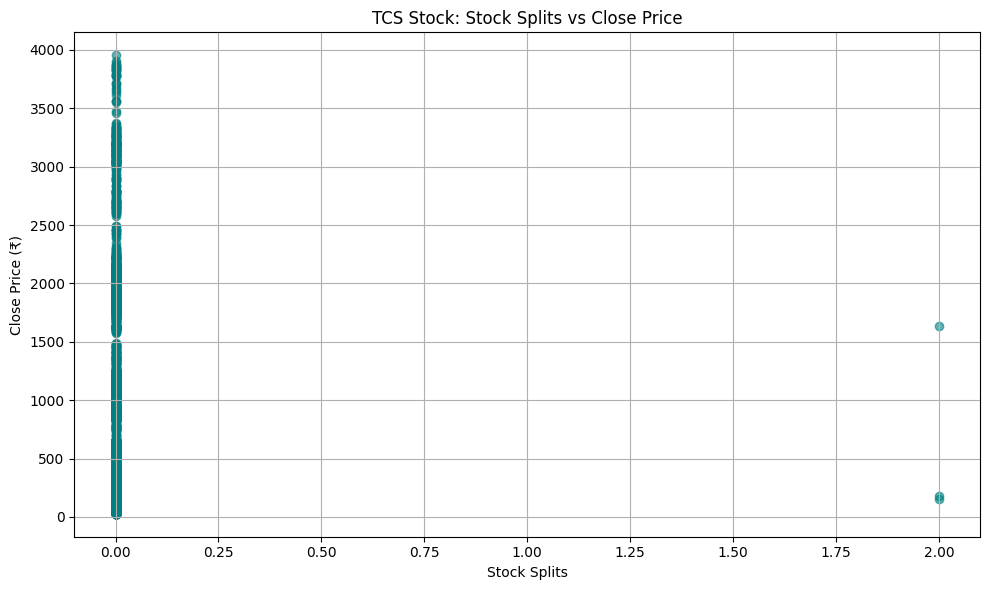

In [65]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Stock Splits'], df['Close'], alpha=0.6, color='teal')
plt.title('TCS Stock: Stock Splits vs Close Price')
plt.xlabel('Stock Splits')
plt.ylabel('Close Price (₹)')
plt.grid(True)
plt.tight_layout()
plt.show()


**Daily returns histogram**

This histogram shows the distribution of daily returns for TCS stock over the observed period. Most returns are tightly clustered around 0%, indicating that on most days, the stock experienced minimal change in price. The distribution is heavily peaked and right-skewed, with a few days showing extreme positive returns above 100% (likely due to corporate actions like stock splits or exceptional market events). Similarly, a small number of outliers show sharp negative returns. Overall, this reflects that TCS stock has been relatively stable on a day-to-day basis, with rare but notable volatility spikes.

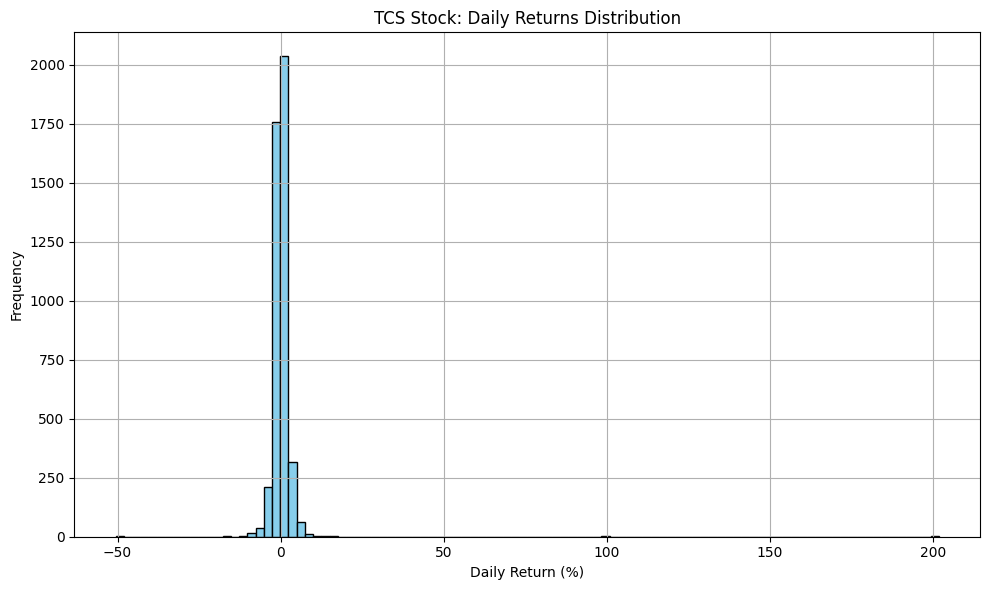

In [66]:
df['Daily Return (%)'] = df['Close'].pct_change() * 100
plt.figure(figsize=(10, 6))
plt.hist(df['Daily Return (%)'].dropna(), bins=100, color='skyblue', edgecolor='black')
plt.title('TCS Stock: Daily Returns Distribution')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


**Monthly Average Close Price Over Time**

This plot of TCS stock’s monthly average close price over time reveals a strong long-term uptrend. From 2004 to around 2013, the price rose steadily but at a moderate pace. Post-2013, the upward momentum intensified, with noticeable surges especially after 2017. The sharpest rise appears around 2020–2021, reflecting rapid growth possibly driven by market optimism or fundamental performance. Despite some short-term dips (e.g., during the 2008 crisis and early 2020 pandemic), the overall trajectory shows consistent strength, making it a clear depiction of TCS’s long-term value appreciation.

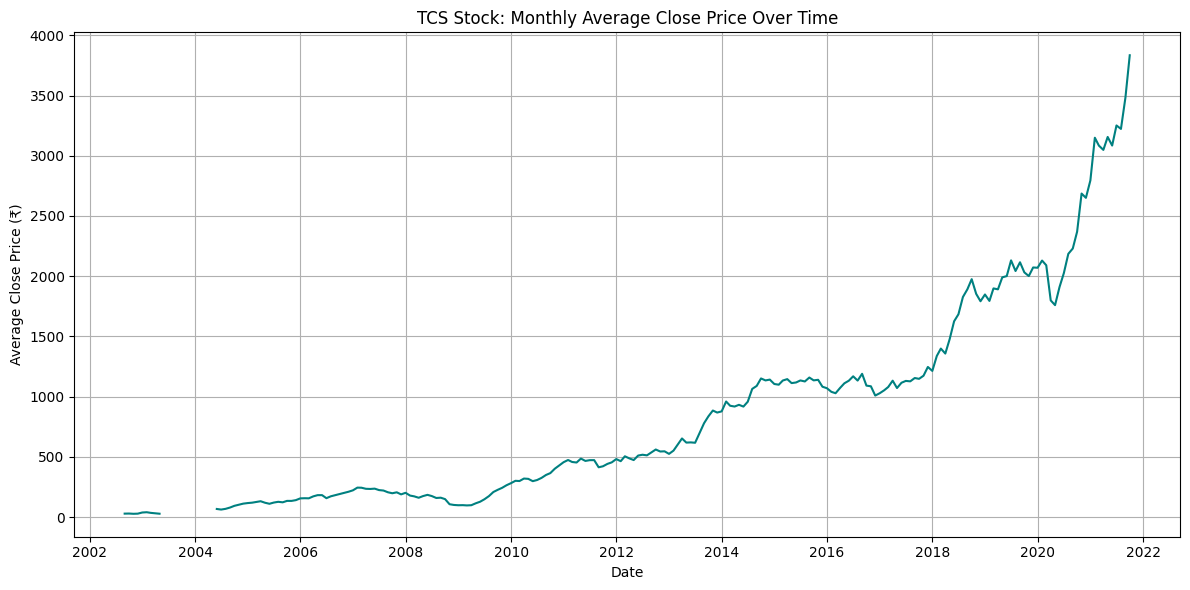

In [67]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
monthly_avg_close = df['Close'].resample('M').mean()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_close, color='teal')
plt.title('TCS Stock: Monthly Average Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Close Price (₹)')
plt.grid(True)
plt.tight_layout()
plt.show()

**Average Close Price by Weekday**

The bar chart illustrates how TCS's average closing price varies across the trading week. The differences between weekdays are marginal, with all averages clustered closely around the ₹860–₹880 range. Slight peaks on Tuesday and Thursday suggest marginally stronger price levels on these days, while Monday and Friday show the lowest averages, though the variation is minimal.

This uniformity indicates that TCS stock does not exhibit a strong weekday effect—i.e., there is no clear, consistent day that significantly outperforms or underperforms. This suggests efficient pricing throughout the week with no observable behavioral biases or cyclical patterns based on trading days.

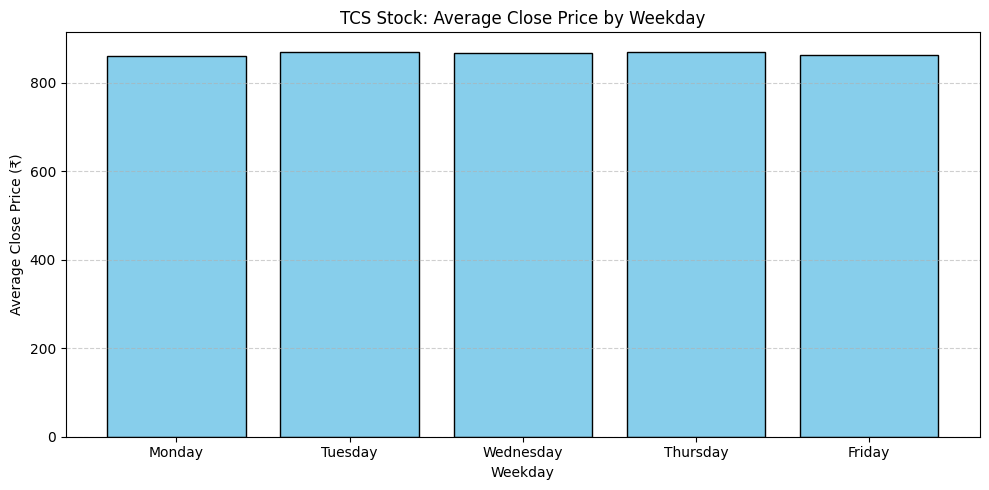

In [68]:
df['Weekday'] = df.index.day_name()
weekday_avg = df.groupby('Weekday')['Close'].mean()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_avg = weekday_avg.reindex(weekday_order)

plt.figure(figsize=(10, 5))
plt.bar(weekday_avg.index, weekday_avg.values, color='skyblue', edgecolor='black')
plt.title('TCS Stock: Average Close Price by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Close Price (₹)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [69]:
original_features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
print("Original feature count:", len(original_features))


Original feature count: 7


**Feature Engineering**



In [70]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Day_of_Week'] = df.index.dayofweek  # Monday = 0, Sunday = 6


In [71]:
df['Prev_Close'] = df['Close'].shift(1)


In [72]:
df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_20'] = df['Close'].rolling(window=20).mean()


In [73]:
df['Volatility_10'] = df['Close'].pct_change().rolling(window=10).std()


In [74]:
df['Price_Change'] = df['Close'] - df['Open']
df['High_Low_Spread'] = df['High'] - df['Low']


In [75]:
df['Volume_MA_5'] = df['Volume'].rolling(window=5).mean()
df['Price_Volume'] = df['Close'] * df['Volume']


In [76]:
df['Had_Dividend'] = (df['Dividends'] > 0).astype(int)
df['Had_Split'] = (df['Stock Splits'] > 0).astype(int)


In [77]:
df['Prev_Close_3'] = df['Close'].shift(3)
df['Prev_Volume_1'] = df['Volume'].shift(1)
df['Rolling_Max_10'] = df['Close'].rolling(window=10).max()
df['Rolling_Min_10'] = df['Close'].rolling(window=10).min()
df['Close_Month_Interaction'] = df['Close'] * df['Month']
df['Open_Close_Ratio'] = df['Open'] / df['Close']


In [78]:
df.dropna(inplace=True)


In [79]:
feature_columns = df.columns.difference(['Close'])

print("Engineered feature count:", len(feature_columns))
print("Feature names:\n", feature_columns.tolist())


Engineered feature count: 31
Feature names:
 ['Close_Month_Interaction', 'Daily Return (%)', 'Day', 'Day_of_Week', 'Dividends', 'Had_Dividend', 'Had_Split', 'High', 'High_Low_Spread', 'Low', 'MA200', 'MA30', 'MA50', 'MA_20', 'MA_5', 'Month', 'Open', 'Open_Close_Ratio', 'Prev_Close', 'Prev_Close_3', 'Prev_Volume_1', 'Price_Change', 'Price_Volume', 'Rolling_Max_10', 'Rolling_Min_10', 'Stock Splits', 'Volatility_10', 'Volume', 'Volume_MA_5', 'Weekday', 'Year']


In [80]:
original = set(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'])
new_features = set(df.columns) - original
print("New features added:", len(new_features))
print("New feature names:\n", sorted(new_features))


New features added: 25
New feature names:
 ['Close_Month_Interaction', 'Daily Return (%)', 'Day', 'Day_of_Week', 'Had_Dividend', 'Had_Split', 'High_Low_Spread', 'MA200', 'MA30', 'MA50', 'MA_20', 'MA_5', 'Month', 'Open_Close_Ratio', 'Prev_Close', 'Prev_Close_3', 'Prev_Volume_1', 'Price_Change', 'Price_Volume', 'Rolling_Max_10', 'Rolling_Min_10', 'Volatility_10', 'Volume_MA_5', 'Weekday', 'Year']


**Feature Selection**

**Correlation Analysis**

After performing correlation analysis between all features and the target variable (Close price), we identified a subset of features with strong positive correlation and clear financial relevance. These include High, Low, Open, Prev_Close, Prev_Close_3, multiple moving averages (MA_5, MA_20, MA30, MA50, MA200), Rolling_Max_10, Rolling_Min_10, Year, Close_Month_Interaction, High_Low_Spread, and Price_Volume. These features demonstrate significant linear relationships with the closing price and are expected to enhance the model's predictive performance. All other features, including those with very low or negative correlation, were excluded from the final set as they provide little to no predictive value and may introduce noise into the model.

Chosen Features:'High', 'Low', 'Open', 'Prev_Close', 'Prev_Close_3', 'MA_5', 'MA_20', 'MA30', 'MA50', 'MA200', 'Rolling_Max_10', 'Rolling_Min_10', 'Year', 'Close_Month_Interaction', 'High_Low_Spread', 'Price_Volume'


In [81]:
df_numeric = df.select_dtypes(include=['number'])
correlation_with_target = df_numeric.corr()['Close'].sort_values(ascending=False)
print(correlation_with_target)


Close                      1.000000
High                       0.999910
Low                        0.999896
Open                       0.999776
Prev_Close                 0.999729
MA_5                       0.999699
Prev_Close_3               0.999239
Rolling_Max_10             0.999235
Rolling_Min_10             0.998991
MA_20                      0.998492
MA30                       0.997769
MA50                       0.996858
MA200                      0.989252
Year                       0.904005
Close_Month_Interaction    0.799351
High_Low_Spread            0.774888
Price_Volume               0.652232
Dividends                  0.058102
Had_Dividend               0.004083
Daily Return (%)           0.000996
Day_of_Week                0.000202
Day                        0.000146
Price_Change              -0.006604
Stock Splits              -0.008033
Had_Split                 -0.008033
Month                     -0.009692
Open_Close_Ratio          -0.030697
Volatility_10             -0

**Select KBest**

Chosen features: 'High', 'Low', 'Open', 'Prev_Close', 'Prev_Close_3',
    'MA_5', 'MA_20', 'MA30', 'MA50', 'MA200',
    'Rolling_Max_10', 'Rolling_Min_10', 'Year',
    'Close_Month_Interaction', 'High_Low_Spread', 'Price_Volume

In [82]:
X = df.drop('Close', axis=1)
y = df['Close']
X_numeric = X.select_dtypes(include=['number'])
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_numeric, y)
feature_scores = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F_score': selector.scores_,
    'P_value': selector.pvalues_
}).sort_values(by='F_score', ascending=False)

print(feature_scores)



                    Feature       F_score       P_value
1                      High  2.368461e+07  0.000000e+00
2                       Low  2.058075e+07  0.000000e+00
0                      Open  9.531475e+06  0.000000e+00
14               Prev_Close  7.864133e+06  0.000000e+00
15                     MA_5  7.074283e+06  0.000000e+00
24             Prev_Close_3  2.798148e+06  0.000000e+00
26           Rolling_Max_10  2.782248e+06  0.000000e+00
27           Rolling_Min_10  2.107790e+06  0.000000e+00
16                    MA_20  1.409861e+06  0.000000e+00
6                      MA30  9.521543e+05  0.000000e+00
7                      MA50  6.751057e+05  0.000000e+00
8                     MA200  1.950831e+05  0.000000e+00
10                     Year  1.905637e+04  0.000000e+00
28  Close_Month_Interaction  7.542834e+03  0.000000e+00
19          High_Low_Spread  6.405030e+03  0.000000e+00
21             Price_Volume  3.155426e+03  0.000000e+00
20              Volume_MA_5  3.445897e+02  4.935

**Random Forest Feature Importance**

Chosen features: High, Low, Rolling_Max_10, MA200, Open, Prev_Close, MA_20, MA_5, MA50, МАЗО, Prev_Close_3

                    Feature    Importance
0                      High  6.386829e-01
1                       Low  1.740550e-01
10           Rolling_Max_10  4.144324e-02
9                     MA200  3.691242e-02
2                      Open  3.507903e-02
3                Prev_Close  2.758783e-02
6                     MA_20  1.174645e-02
5                      MA_5  1.116816e-02
8                      MA50  9.994983e-03
7                      MA30  7.529427e-03
4              Prev_Close_3  4.449402e-03
11           Rolling_Min_10  1.104031e-03
13  Close_Month_Interaction  2.312176e-04
15             Price_Volume  7.918735e-06
14          High_Low_Spread  7.678022e-06
12                     Year  3.669846e-07


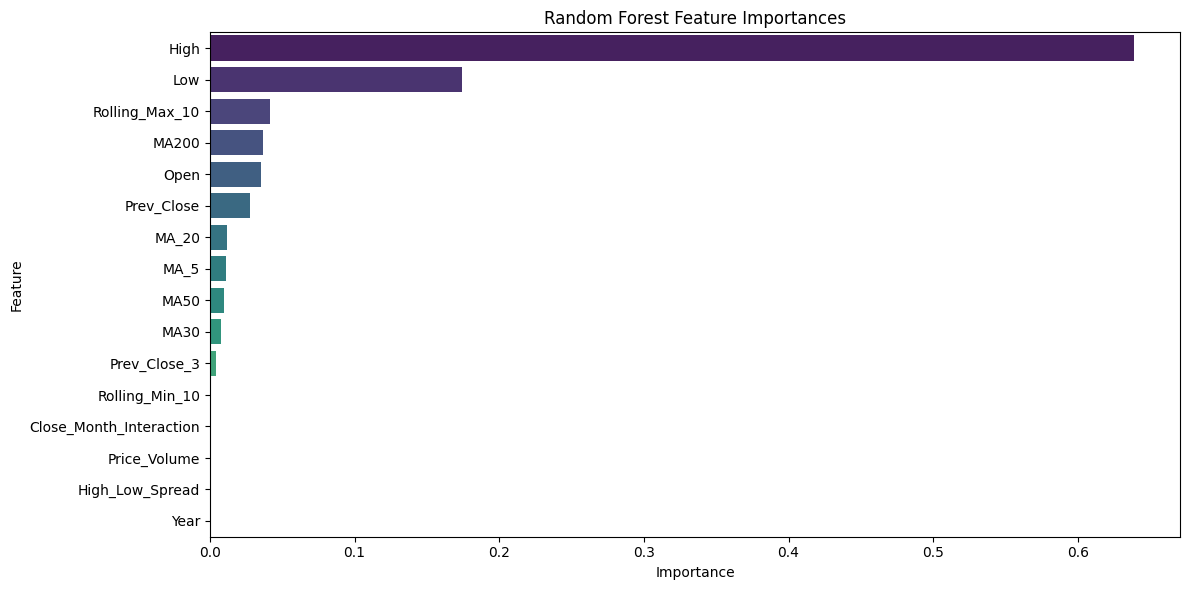

In [83]:
selected_features = [
    'High', 'Low', 'Open', 'Prev_Close', 'Prev_Close_3',
    'MA_5', 'MA_20', 'MA30', 'MA50', 'MA200',
    'Rolling_Max_10', 'Rolling_Min_10', 'Year',
    'Close_Month_Interaction', 'High_Low_Spread', 'Price_Volume'
]

X = df[selected_features]
y = df['Close']
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(importance_df)

#Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()


**RFE**

Final feature set:

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
selected_features = [
    'High', 'Low', 'Rolling_Max_10', 'MA200', 'Open', 'Prev_Close',
    'MA_20', 'MA_5', 'MA50', 'MA30', 'Prev_Close_3'
]

X = df[selected_features]
y = df['Close']
model = LinearRegression()
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)

selected = pd.Series(rfe.support_, index=selected_features)
ranking = pd.Series(rfe.ranking_, index=selected_features)

print("Selected Features:\n", selected[selected == True].index.tolist())
print("\nFeature Ranking:\n", ranking.sort_values())


Selected Features:
 ['High', 'Low', 'Open', 'Prev_Close', 'MA_5']

Feature Ranking:
 High              1
Low               1
Prev_Close        1
Open              1
MA_5              1
Prev_Close_3      2
MA_20             3
MA50              4
MA30              5
Rolling_Max_10    6
MA200             7
dtype: int64


**Model Training and Prediction**

In [85]:
from sklearn.model_selection import train_test_split

X_final = df[['High', 'Low', 'Open', 'Prev_Close', 'MA_5']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)


Linear Regression Mean Squared Error: 42.269542341133985
Linear Regression R-Squared Score: 0.9999392049864402


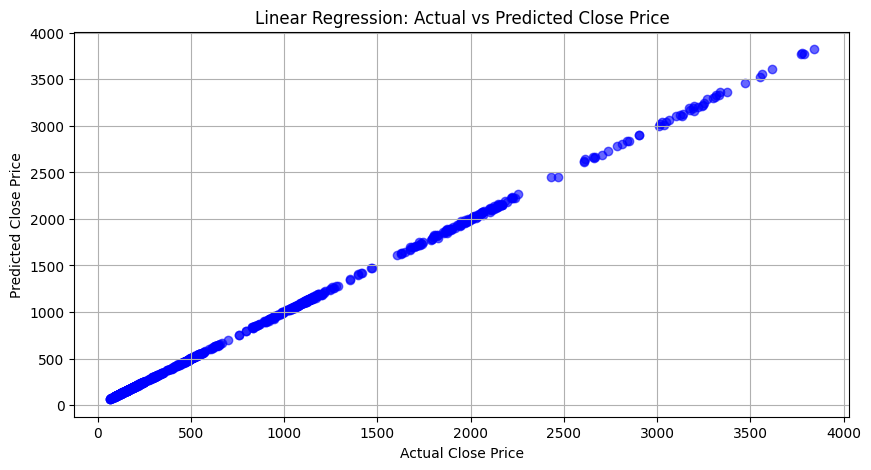

In [86]:
#Linear Regression Model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Linear Regression R-Squared Score:", r2_score(y_test, y_pred))

#Actual vs predicted plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Linear Regression: Actual vs Predicted Close Price")
plt.grid(True)
plt.show()

XGBoost Mean Squared Error: 216.49792645215345
XGBoost R² Score: 0.9996886175329718


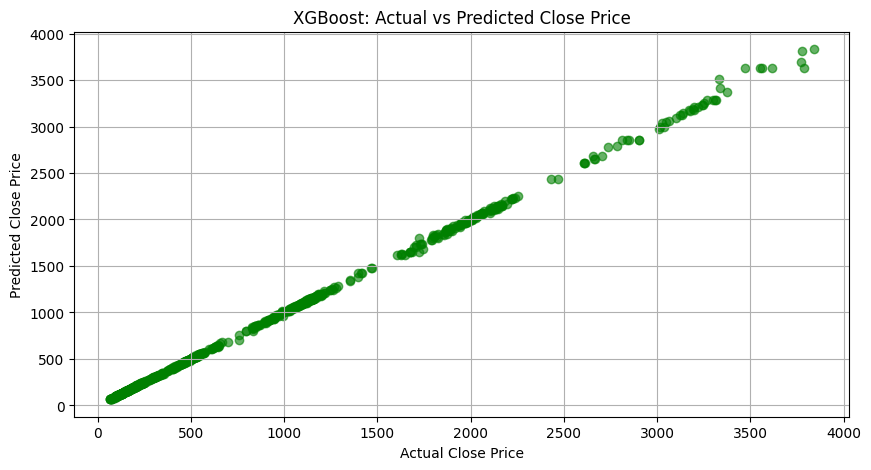

In [87]:
#XGBoost Regressor

features = ['High', 'Low', 'Open', 'Prev_Close', 'MA_5']
X = df[features]
y = df['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost Mean Squared Error:", mse)
print("XGBoost R² Score:", r2)

#Actual vs Predicted plot

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("XGBoost: Actual vs Predicted Close Price")
plt.grid(True)
plt.show()


Epoch 1/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0028
Epoch 2/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3.3761e-05
Epoch 3/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 3.4095e-05
Epoch 4/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 2.8598e-05
Epoch 5/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.9158e-05
Epoch 6/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 2.8656e-05
Epoch 7/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.9598e-05
Epoch 8/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 2.5038e-05
Epoch 9/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 2.6781e-05
Epoch 10/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 2.5830e-05
Epoch 11/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 2.2778e-05
Epoch 12/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 2.8177e-05
Epoch 13/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.4958e-05
Epoch 14/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 2.

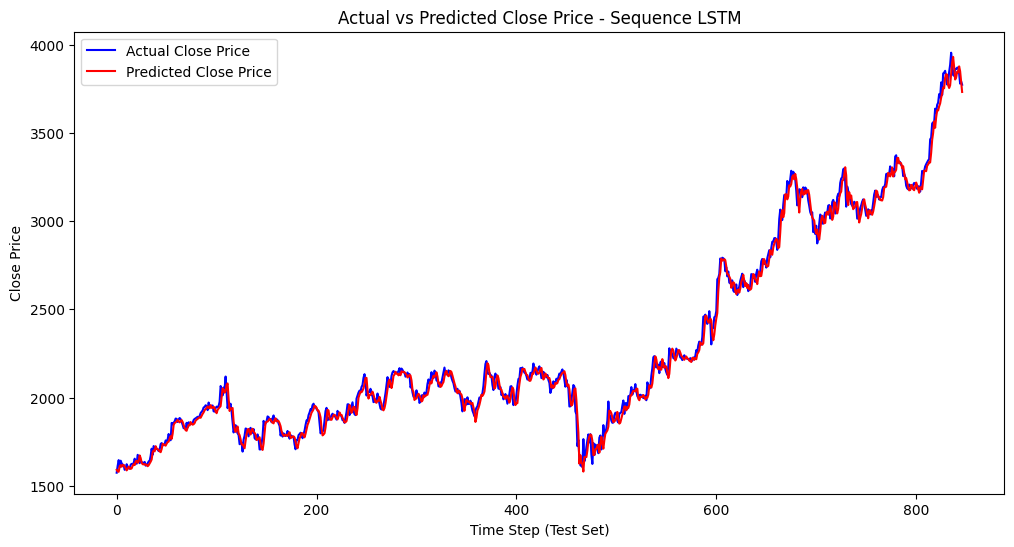

In [88]:
#LSTM Model

features = ['High', 'Low', 'Open', 'Prev_Close', 'MA_5']
target = 'Close'
df_model = df[features + [target]].copy()
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model)
sequence_length = 30
X, y = [], []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, :-1])
    y.append(scaled_data[i, -1])

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
model = Sequential()
model.add(LSTM(units=64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=1)
y_pred_scaled = model.predict(X_test)
y_pred, y_true = [], []

for i in range(len(X_test)):
    last_features = X_test[i, -1, :]
    dummy_row = np.append(last_features, y_pred_scaled[i])
    y_pred.append(scaler.inverse_transform([dummy_row])[0][-1])
    true_dummy_row = np.append(last_features, y_test[i])
    y_true.append(scaler.inverse_transform([true_dummy_row])[0][-1])

y_pred = np.array(y_pred)
y_true = np.array(y_true)
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
print("LSTM MAE:", mae)
print("LSTM MSE:", mse)

#Actual vs Predited Plot
plt.figure(figsize=(12,6))
plt.plot(y_true, label='Actual Close Price', color='blue')
plt.plot(y_pred, label='Predicted Close Price', color='red')
plt.title("Actual vs Predicted Close Price - Sequence LSTM")
plt.xlabel("Time Step (Test Set)")
plt.ylabel("Close Price")
plt.legend()
plt.show()


## Final Model Comparison & Conclusion
Among the models evaluated:
- **Linear Regression** achieved the best overall performance with an R² of 0.9999 and lowest MSE.
- **XGBoost** also performed well but with slightly higher error.
- **LSTM**, though more complex, underperformed compared to simpler models.

Conclusion: For this dataset and problem, linear models with strong feature engineering outperform more complex architectures. The final model is ready for deployment.
